##### About this notebook:

In [ ]:
#-----------------------------------------------------------------------------------------------------------------------------
# Author:             Erick Rico Esparza
# Dates:              Nov 12 - Nov 26, 2025
# Description:        Generate monthly seasonality
#-----------------------------------------------------------------------------------------------------------------------------

# Final Week

## 1. Libraries and setup

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [27]:
# Loading clean data from previous weeks
df = pd.read_csv("cdmx_citymean_daily_2012_2024.csv")

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4555 entries, 0 to 4554
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    4555 non-null   object 
 1   NO2     4555 non-null   float64
 2   O3      4555 non-null   float64
 3   PM10    4555 non-null   float64
 4   PM2.5   4555 non-null   float64
 5   SO2     4555 non-null   float64
dtypes: float64(5), object(1)
memory usage: 213.6+ KB


In [29]:
# Converting DATE column to datetime and verifying data types
df["DATE"] = pd.to_datetime(df["DATE"])
df.info()

# Extracting the month
df['MONTH'] = df['DATE'].dt.month

# List of pollutants to plot
pollutants = ["PM2.5", "PM10", "O3", "NO2", "SO2"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4555 entries, 0 to 4554
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    4555 non-null   datetime64[ns]
 1   NO2     4555 non-null   float64       
 2   O3      4555 non-null   float64       
 3   PM10    4555 non-null   float64       
 4   PM2.5   4555 non-null   float64       
 5   SO2     4555 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 213.6 KB


## 2. Monthly mean for Mexico City

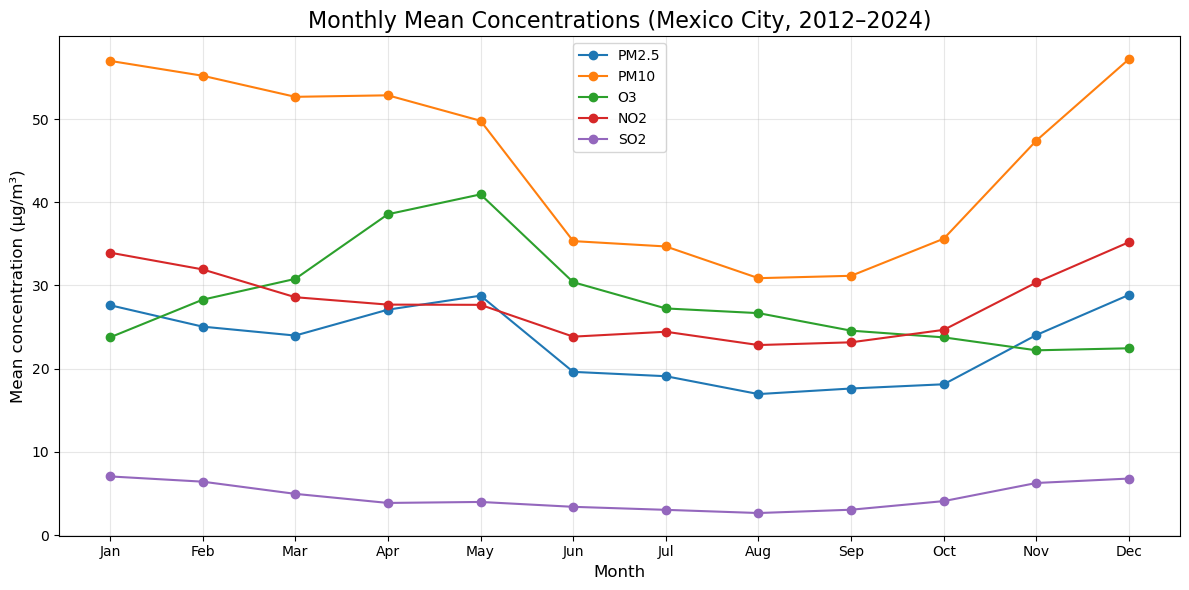

In [34]:
# Calculating monthly averages
monthly_mean = df.groupby('MONTH')[pollutants].mean()

# Plotting
plt.figure(figsize=(12,6))

for p in pollutants:
    plt.plot(monthly_mean.index,
             monthly_mean[p],
             marker='o',
             label=p)

plt.title("Monthly Mean Concentrations (Mexico City, 2012–2024)", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Mean concentration (µg/m³)", fontsize=12)
plt.xticks(range(1,13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("fig5.png", dpi=300)
plt.show()


In [41]:
# Month labels dictionary
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# Show table with months (rows) x pollutants (columns)
display(monthly_mean.rename(index=month_labels).round(3))

,PM2.5,PM10,O3,NO2,SO2
MONTH,,,,,
Jan,27.628,57.002,23.759,33.947,7.043
Feb,25.052,55.215,28.289,31.932,6.413
Mar,23.979,52.681,30.793,28.589,4.947
Apr,27.092,52.862,38.565,27.700,3.855
May,28.773,49.800,40.952,27.672,3.975
Jun,19.614,35.335,30.395,23.848,3.388
Jul,19.092,34.691,27.239,24.437,3.026
Aug,16.944,30.879,26.675,22.838,2.643
Sep,17.613,31.164,24.567,23.167,3.040
